# Exploratory Data Analysis
**Competition:** Not Controllable Electricity Balance Forecast  
**Target:** `Electricity_balance_not_controllable` = `Load` - `Solar_power` - `Wind_power`

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (14, 4)

DATA = 'data/'
train = pd.read_csv(DATA + 'train.csv', parse_dates=['date'])
test  = pd.read_csv(DATA + 'test.csv',  parse_dates=['date'])

# remove tz info for convenience
train['date'] = train['date'].dt.tz_localize(None)
test['date']  = test['date'].dt.tz_localize(None)

print('train:', train.shape, '  test:', test.shape)
train.head(3)

train: (137376, 24)   test: (17520, 20)


,Id,date,Date,month,year,tod,toy,week_number,period_hour_changed,temperature,...,day_type_week_jf,period_holiday,period_christmas,period_summer,nebulosity_by_solar_power_weights,wind_by_wind_power_weights,Electricity_balance_not_controllable,Load,Solar_power,Wind_power
0,0,2013-03-02 00:00:00,20130302,3,2013,0,0.167,201309,0.0,276.240938,...,1.0,1,0,0,91.698225,4.239487,72585.0,74435.0,0.0,1850.0
1,1,2013-03-02 00:30:00,20130302,3,2013,1,0.167,201309,0.0,276.136188,...,1.0,1,0,0,92.581549,4.198898,70721.0,72525.0,0.0,1804.0
2,2,2013-03-02 01:00:00,20130302,3,2013,2,0.167,201309,0.0,276.031438,...,1.0,1,0,0,93.464873,4.158309,68207.0,69948.0,0.0,1741.0


## 1. Dataset Info & Missing Values

In [32]:
print('=== dtypes ===')
print(train.dtypes)
print('\n=== Missing values ===')
print(train.isnull().sum())
print('\n=== Describe (numeric) ===')
train.describe().round(2)

=== dtypes ===
Id                                               int64
date                                    datetime64[ns]
Date                                             int64
month                                            int64
year                                             int64
tod                                              int64
toy                                            float64
week_number                                      int64
period_hour_changed                            float64
temperature                                    float64
nebulosity                                     float64
wind                                           float64
day_type_week                                    int64
day_type_jf                                    float64
day_type_week_jf                               float64
period_holiday                                   int64
period_christmas                                 int64
period_summer                                    i

,Id,date,Date,month,year,tod,toy,week_number,period_hour_changed,temperature,...,day_type_week_jf,period_holiday,period_christmas,period_summer,nebulosity_by_solar_power_weights,wind_by_wind_power_weights,Electricity_balance_not_controllable,Load,Solar_power,Wind_power
count,137376.00,137376,137376.00,137376.00,137376.00,137376.00,137376.00,137376.00,137376.00,137376.00,...,137376.00,137376.00,137376.00,137376.00,137376.00,137376.00,137376.00,137376.00,137376.00,137376.00
mean,68687.50,2017-01-30 23:45:00.000000512,20166422.80,6.63,2016.57,23.50,0.51,201684.37,0.59,286.11,...,0.31,0.42,0.04,0.16,77.61,3.60,49609.25,53505.24,1014.71,2881.28
min,0.00,2013-03-02 00:00:00,20130302.00,1.00,2013.00,0.00,0.00,201301.00,0.00,265.99,...,0.00,0.00,0.00,0.00,20.38,0.71,23428.00,29124.00,0.00,21.00
25%,34343.75,2015-02-15 11:52:30,20150215.00,4.00,2015.00,11.75,0.26,201507.00,0.00,281.03,...,0.00,0.00,0.00,0.00,70.74,2.52,40891.00,44586.00,0.00,1161.00
50%,68687.50,2017-01-30 23:45:00,20170130.50,7.00,2017.00,23.50,0.51,201705.00,1.00,285.67,...,0.00,0.00,0.00,0.00,79.92,3.32,47892.00,52011.00,18.00,2112.00
75%,103031.25,2019-01-16 11:37:30,20190116.00,10.00,2019.00,35.25,0.75,201903.00,1.00,290.86,...,1.00,1.00,0.00,0.00,87.15,4.40,57100.25,61510.00,1724.00,3839.00
max,137375.00,2020-12-31 23:30:00,20201231.00,12.00,2020.00,47.00,1.00,202053.00,1.00,309.60,...,1.00,1.00,1.00,1.00,99.32,12.01,91969.00,96272.00,7551.00,13552.00
std,39657.18,NaN,22565.41,3.41,2.26,13.85,0.28,225.65,0.49,6.59,...,0.46,0.49,0.21,0.37,12.94,1.45,11471.33,11656.99,1525.48,2415.05


## 2. Target Distribution

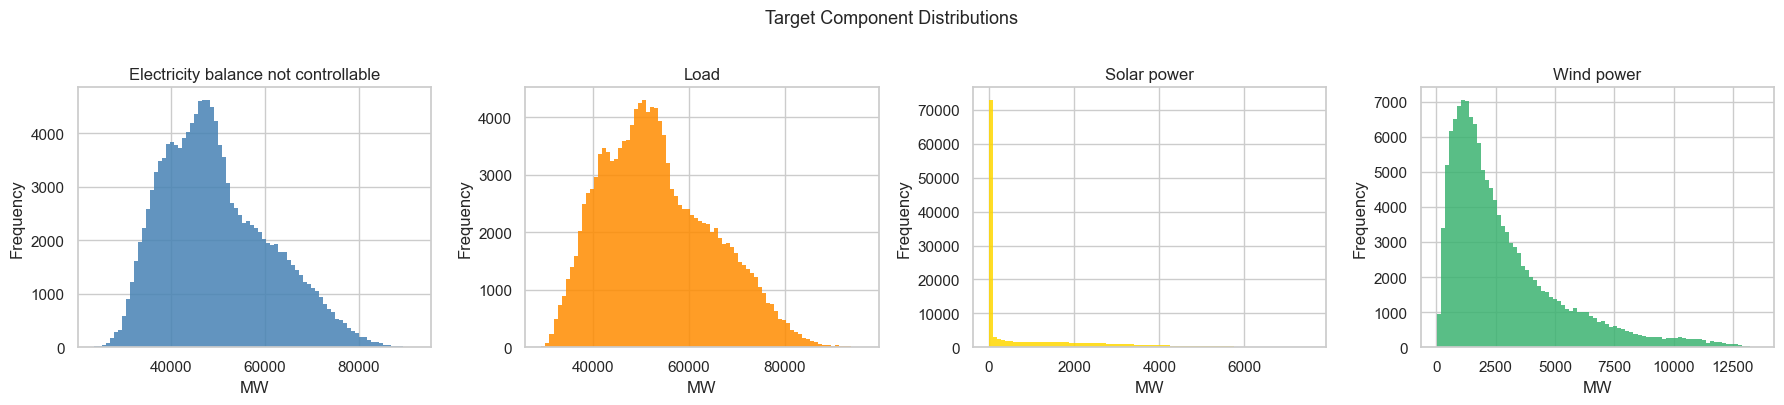

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
targets = ['Electricity_balance_not_controllable', 'Load', 'Solar_power', 'Wind_power']
colors = ['steelblue', 'darkorange', 'gold', 'mediumseagreen']
for ax, col, c in zip(axes, targets, colors):
    train[col].plot.hist(bins=80, ax=ax, color=c, edgecolor='none', alpha=0.85)
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('MW')
plt.suptitle('Target Component Distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Time Series Overview

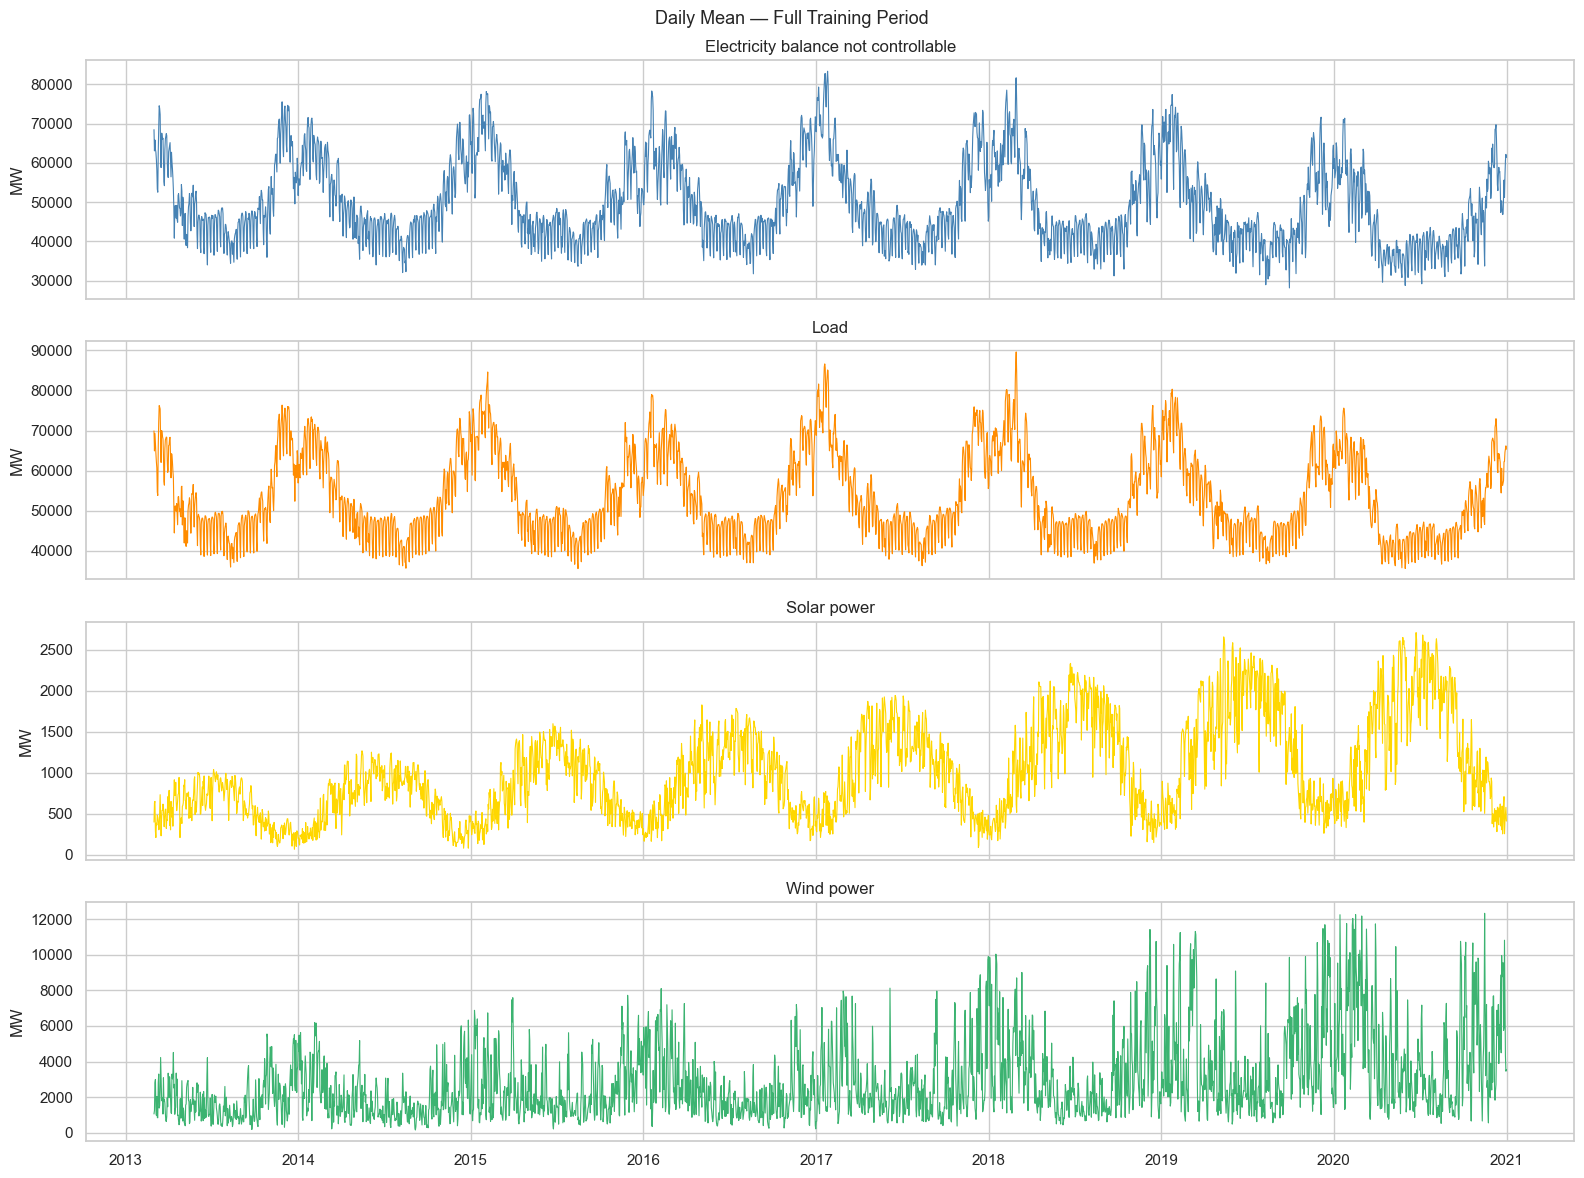

In [34]:
# Daily aggregates
daily = train.set_index('date').resample('D')[targets].mean()

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
for ax, col, c in zip(axes, targets, colors):
    ax.plot(daily.index, daily[col], lw=0.8, color=c)
    ax.set_ylabel('MW')
    ax.set_title(col.replace('_', ' '))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Daily Mean — Full Training Period', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Seasonality Analysis

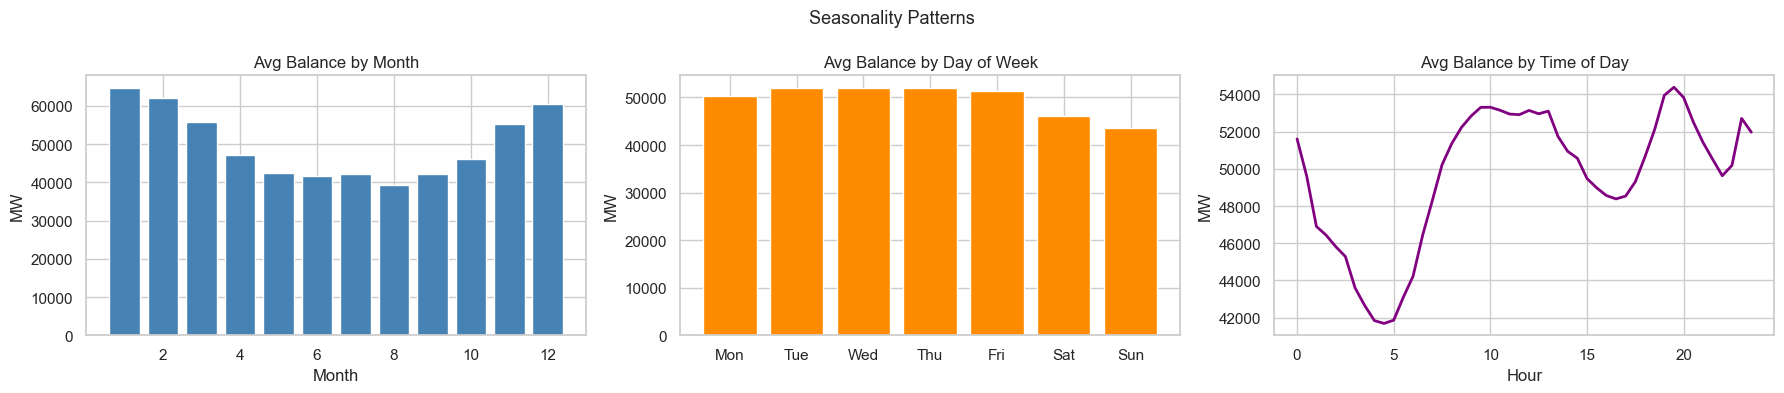

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Monthly
monthly = train.groupby('month')['Electricity_balance_not_controllable'].mean()
axes[0].bar(monthly.index, monthly.values, color='steelblue')
axes[0].set_title('Avg Balance by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('MW')

# Day of week
dow = train.groupby('day_type_week')['Electricity_balance_not_controllable'].mean()
labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar(range(7), dow.values, color='darkorange')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(labels)
axes[1].set_title('Avg Balance by Day of Week')
axes[1].set_ylabel('MW')

# Time of day
tod = train.groupby('tod')['Electricity_balance_not_controllable'].mean()
axes[2].plot(tod.index / 2, tod.values, color='purple', lw=2)
axes[2].set_title('Avg Balance by Time of Day')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('MW')

plt.suptitle('Seasonality Patterns', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Load vs Solar vs Wind — Daily Profile by Season

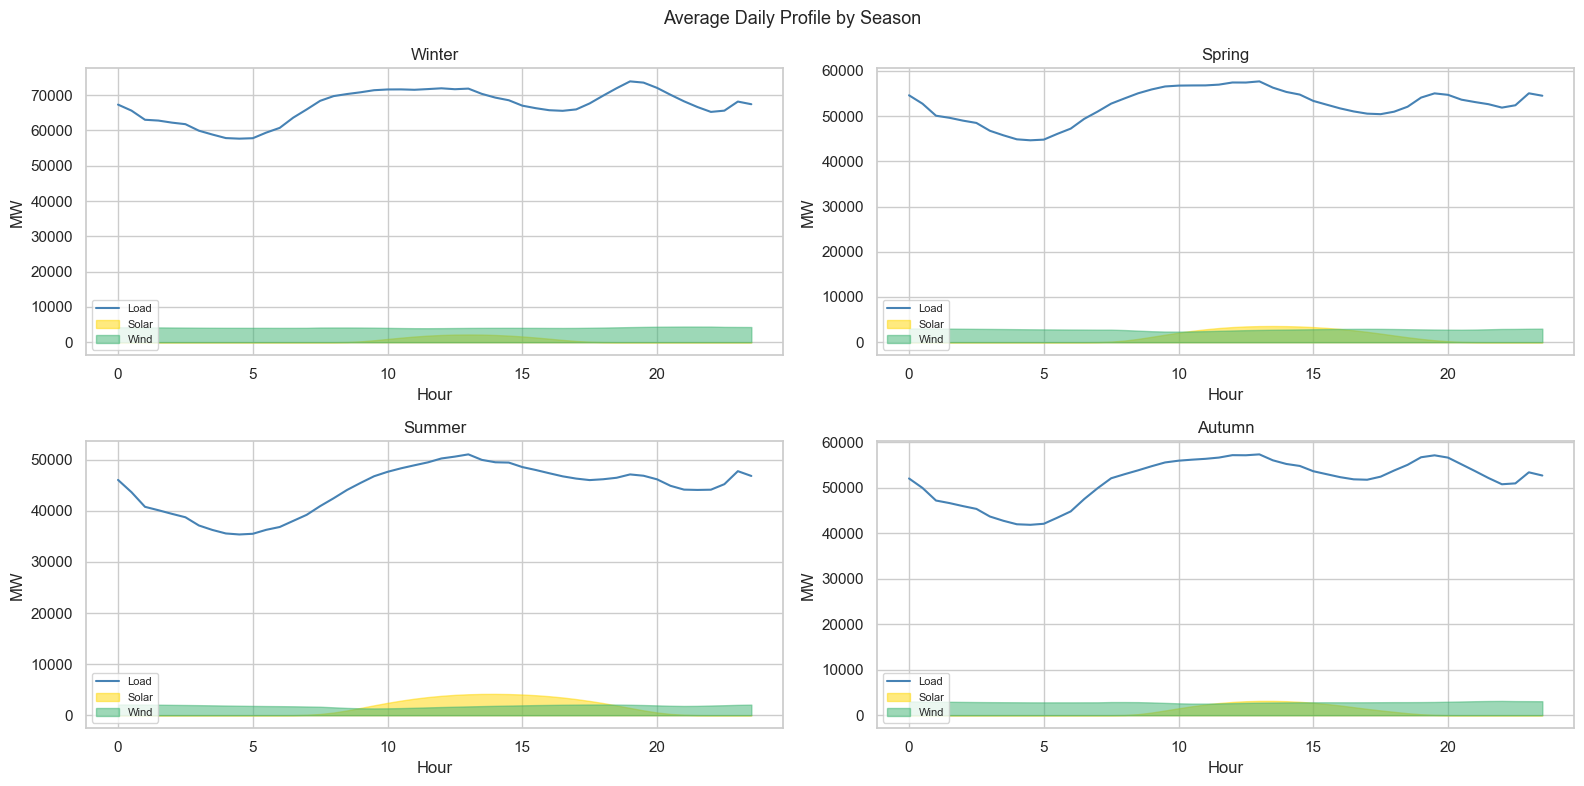

In [36]:
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
train['season'] = train['month'].map(season_map)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, season in zip(axes.flatten(), ['Winter', 'Spring', 'Summer', 'Autumn']):
    df_s = train[train['season'] == season].groupby('tod')[['Load','Solar_power','Wind_power']].mean()
    ax.plot(df_s.index/2, df_s['Load'], label='Load', color='steelblue')
    ax.fill_between(df_s.index/2, df_s['Solar_power'], alpha=0.5, label='Solar', color='gold')
    ax.fill_between(df_s.index/2, df_s['Wind_power'], alpha=0.5, label='Wind', color='mediumseagreen')
    ax.set_title(season)
    ax.set_xlabel('Hour')
    ax.set_ylabel('MW')
    ax.legend(fontsize=8)
plt.suptitle('Average Daily Profile by Season', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Weather Feature Correlations

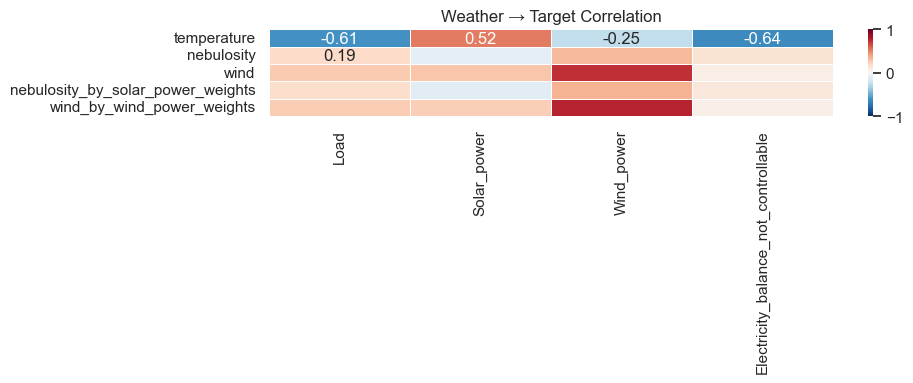

In [37]:
weather_cols = ['temperature', 'nebulosity', 'wind',
                'nebulosity_by_solar_power_weights', 'wind_by_wind_power_weights']
target_cols  = ['Load', 'Solar_power', 'Wind_power', 'Electricity_balance_not_controllable']

corr = train[weather_cols + target_cols].corr().loc[weather_cols, target_cols]

plt.figure(figsize=(10, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Weather → Target Correlation')
plt.tight_layout()
plt.show()

## 7. Temperature vs Load

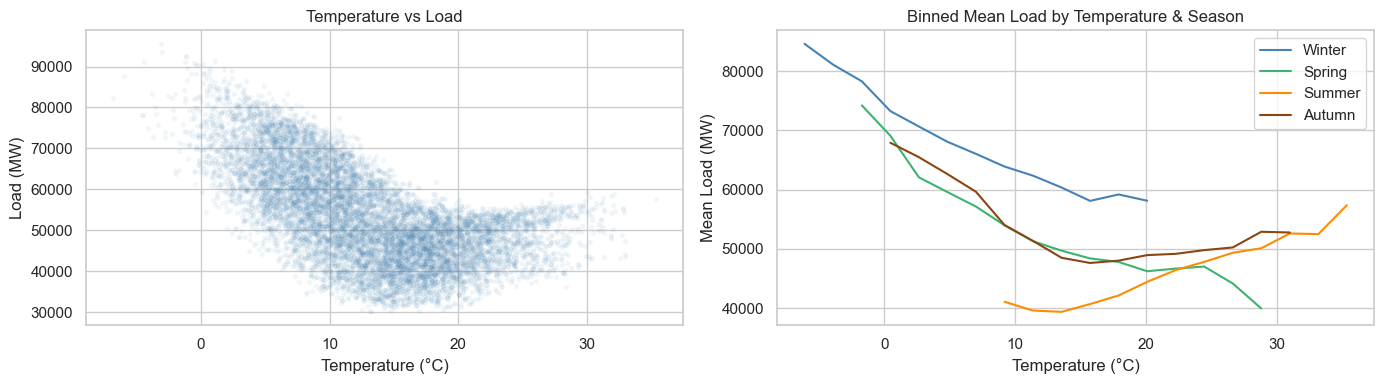

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Scatter (sampled)
s = train.sample(10000, random_state=42)
axes[0].scatter(s['temperature'] - 273.15, s['Load'], alpha=0.05, s=8, color='steelblue')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Load (MW)')
axes[0].set_title('Temperature vs Load')

# Binned mean with season colour
train['temp_bin'] = pd.cut(train['temperature'] - 273.15, bins=20)
binned = train.groupby(['temp_bin','season'])['Load'].mean().reset_index()
for season, c in zip(['Winter','Spring','Summer','Autumn'],
                     ['steelblue','mediumseagreen','darkorange','saddlebrown']):
    d = binned[binned['season'] == season]
    axes[1].plot([iv.mid for iv in d['temp_bin']], d['Load'], label=season, color=c)
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Mean Load (MW)')
axes[1].set_title('Binned Mean Load by Temperature & Season')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Train/Test Feature Distribution Check

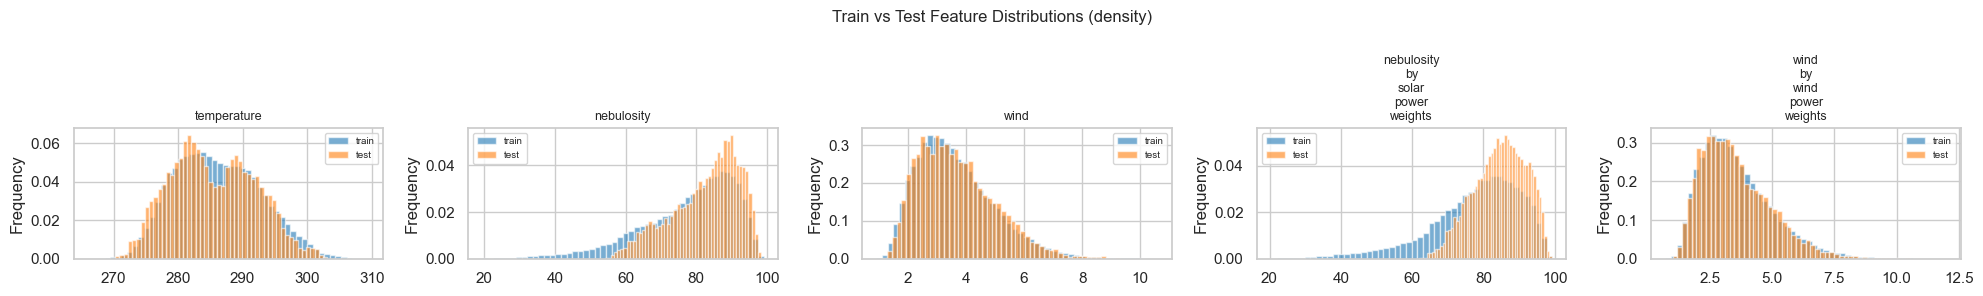

In [39]:
feat_cols = ['temperature', 'nebulosity', 'wind',
             'nebulosity_by_solar_power_weights', 'wind_by_wind_power_weights']

fig, axes = plt.subplots(1, len(feat_cols), figsize=(20, 3))
for ax, col in zip(axes, feat_cols):
    train[col].plot.hist(bins=50, ax=ax, alpha=0.6, label='train', density=True)
    test[col].plot.hist(bins=50, ax=ax, alpha=0.6, label='test', density=True)
    ax.set_title(col.replace('_', '\n'), fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle('Train vs Test Feature Distributions (density)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Holiday & Calendar Flag Effects

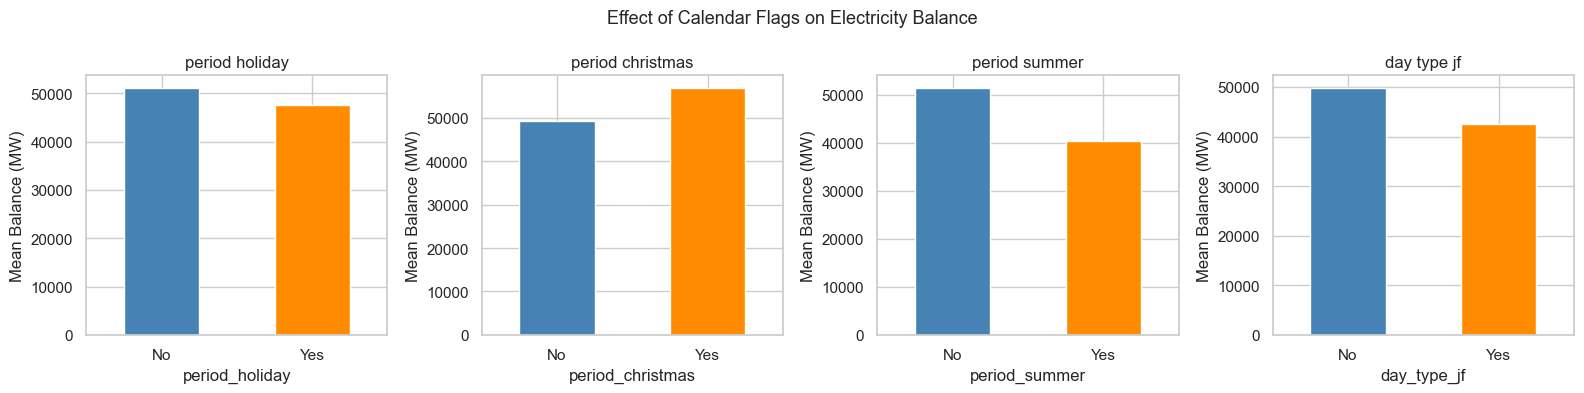

In [40]:
flag_cols = ['period_holiday', 'period_christmas', 'period_summer', 'day_type_jf']
fig, axes = plt.subplots(1, len(flag_cols), figsize=(16, 4))
for ax, col in zip(axes, flag_cols):
    train.groupby(col)['Electricity_balance_not_controllable'].mean().plot.bar(
        ax=ax, color=['steelblue','darkorange'], edgecolor='white')
    ax.set_title(col.replace('_', ' '))
    ax.set_ylabel('Mean Balance (MW)')
    ax.set_xticklabels(['No','Yes'], rotation=0)
plt.suptitle('Effect of Calendar Flags on Electricity Balance', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Summary Insights

| Finding | Detail |
|---|---|
| **Target identity** | `Balance = Load − Solar − Wind` (exact, 0 error) |
| **Strong seasonality** | Load ~70k MW in Jan, ~42k in Aug (~65% swing) |
| **Daily cycle** | Morning ramp 6–9h, evening peak 18–21h |
| **Temperature effect** | U-shaped: cold → heating load; hot → cooling load |
| **Solar** | Zero at night, strong in summer midday; `nebulosity_by_solar_power_weights` is the key predictor |
| **Wind** | Highly stochastic; `wind_by_wind_power_weights` captures geographic weighted speed |
| **COVID dip** | 2020 avg Load ~4k MW lower than 2016–2019 |
| **No missing values** | Both train and test are complete |
| **Train/test shift** | Small but present in temperature (test year 2021 is slightly milder) |